# PINNs y sismología coronal: cuándo la física en la pérdida realmente sirve

**Curso:** Astrofísica Computacional 2026-I
**Tema:** Physics-Informed Neural Networks (PINNs)
**Acompaña a:** `Presentación de PINNs y Física Solar.pdf`

---

Una PINN se resume en una sola línea:

$$
\mathcal{L}_{\rm total}
= \mathcal{L}_{\rm datos}
+ \lambda_{\rm fis}\,\mathcal{L}_{\rm física}
+ \lambda_{\rm ci}\,\mathcal{L}_{\rm cond.\ iniciales}.
$$

Pero esa línea, por sí sola, no dice **cuándo conviene usarla**. Este cuaderno
trata precisamente esa pregunta, y la responde con un experimento controlado en
un problema de física solar: la oscilación transversal amortiguada de un lazo
coronal.

## La tesis del cuaderno

> Para el **problema directo** (conozco la ecuación y sus parámetros, quiero
> $u(t)$), una PINN es una mala idea: RK4 es miles de veces más rápido y
> millones de veces más preciso. Para el **problema inverso y de asimilación de
> datos** (tengo observaciones escasas, ruidosas y con huecos, y quiero
> reconstruir el estado y estimar parámetros físicos), la física dentro de la
> pérdida es lo que convierte un ajuste sin sentido en una medición.

Vamos a demostrar las dos mitades de esa afirmación, con números.

## El experimento controlado

Entrenamos **la misma red, con el mismo optimizador, sobre los mismos datos**.
Lo único que cambia es la función de pérdida:

| Modelo | Pérdida | Qué sabe |
|---|---|---|
| Caja negra | $\mathcal{L}_{\rm datos}$ | 14 puntos ruidosos |
| PINN | $\mathcal{L}_{\rm datos}+\lambda_{\rm fis}\mathcal{L}_{\rm física}+\lambda_{\rm ci}\mathcal{L}_{\rm ci}$ | los mismos 14 puntos **+ la EDO** |

Y no juzgamos solo por cómo se ve la curva. Juzgamos por **observables físicos**:

1. el desplazamiento $u(t)$,
2. la velocidad $v(t)=\dot u$,
3. el residuo de la ecuación de movimiento,
4. la **energía** $E(t)$ y su ley de disipación $\dot E=-2\beta v^2\le 0$,
5. el retrato de fase $(u,v)$.

El punto central: una red que solo ve datos puede pasar exactamente por todos
los puntos observados **y aun así crear energía de la nada**. Eso no es un
detalle estético; es una violación de la física que invalida cualquier
diagnóstico posterior.

## Contenido

| § | Tema |
|---|---|
| 1 | Qué es una PINN y cuándo tiene (y no tiene) sentido |
| 2 | El sistema físico, sus observables y la conexión solar |
| 3 | Solución exacta y referencia RK4 |
| 4 | El escenario observacional: datos escasos, ruidosos, con hueco |
| 5 | La red y las dos pérdidas |
| 6 | Entrenamiento (Adam + L-BFGS) |
| 7 | Diagnóstico multi-observable: quién respeta la física |
| 8 | Animación: cómo la física dobla la curva durante el entrenamiento |
| 9 | El caso donde la PINN gana: problema inverso y sismología coronal |
| 10 | Honestidad computacional: PINN vs RK4 |
| 11 | Tareas |


## 1. Qué es una PINN, y cuándo tiene sentido

### 1.1 La red como *ansatz* continuo y diferenciable

Una red neuronal densa con activaciones suaves define una función

$$
u_\theta:\ t\ \longmapsto\ u_\theta(t),
$$

infinitamente diferenciable y con parámetros $\theta$ (pesos y sesgos). No es una
tabla de valores: es una **función analítica por composición**, así que
$\dot u_\theta$ y $\ddot u_\theta$ existen y se pueden evaluar **exactamente**
(hasta precisión de máquina) con diferenciación automática. No hay diferencias
finitas, no hay error de truncamiento en la derivada.

Esta es la propiedad que hace posible todo lo demás: si puedo derivar la red
exactamente, puedo **evaluar la ecuación diferencial sobre la red** y castigar
cuánto la incumple.

### 1.2 El residuo como función de pérdida

Para la EDO $\ddot u+2\beta\dot u+\omega_0^2u=0$ definimos el residuo

$$
r_\theta(t)=\ddot u_\theta(t)+2\beta\dot u_\theta(t)+\omega_0^2u_\theta(t),
$$

que sería idénticamente cero si $u_\theta$ resolviera la ecuación. La pérdida
física es su promedio cuadrático sobre puntos de colocación $\{t_j\}$ que
**no necesitan datos** — se pueden poner donde uno quiera, incluso donde no hay
observaciones:

$$
\mathcal{L}_{\rm física}=\frac{1}{N_c}\sum_j r_\theta(t_j)^2 .
$$

Aquí está el truco que importa: los puntos de colocación pueblan los huecos de
la cobertura observacional. La física **es** el dato que falta.

### 1.3 Qué NO es una PINN

Tres malentendidos frecuentes:

- **No es un integrador numérico mejorado.** Resolver una EDO/EDP conocida con
  una PINN es, en la enorme mayoría de casos, más lento y menos preciso que un
  método clásico. Lo verificaremos en §10.
- **No garantiza que se cumpla la física.** La pérdida física es un término
  *blando*: penaliza el incumplimiento, no lo prohíbe. Una PINN mal entrenada
  viola la ecuación tranquilamente. Solo las restricciones *duras* (imponer la
  condición inicial en la arquitectura, por ejemplo) se cumplen exactamente.
- **No es magia con datos escasos.** Si la ecuación que impones está mal, la PINN
  te dará con gran confianza una respuesta equivocada. La física en la pérdida es
  una hipótesis, y se propaga a las conclusiones.

### 1.4 Cuándo sí, cuándo no

| Situación | ¿PINN? | Por qué |
|---|---|---|
| Resolver una EDO/EDP con parámetros conocidos | No | RK4, diferencias finitas o espectral son órdenes de magnitud mejores |
| Datos escasos/ruidosos + ecuación conocida, quiero el estado continuo | Sí | La física regulariza e interpola donde no hay datos |
| **Problema inverso**: estimar parámetros físicos desde observaciones | Sí, el caso estrella | Los parámetros son simplemente variables entrenables más |
| Reconstruir variables **no observadas** (velocidad, presión) desde una sí observada | Sí | La ecuación acopla lo observado con lo oculto |
| Geometría o condiciones de frontera complicadas, malla difícil | Sí | Sin malla; solo puntos de colocación |
| Dinámica rígida (*stiff*) o multiescala | Con cuidado | Patologías de gradiente conocidas; suele fallar sin trucos |
| Se necesita precisión de máquina | No | Difícil bajar de $10^{-5}$–$10^{-6}$ relativo |

En física solar, las filas favorables describen la situación real: cadencia
limitada, ruido, líneas de visión que integran, variables del plasma que no se
miden directamente, y ecuaciones MHD que sí conocemos. Ese es el nicho.


## 2. El sistema físico y sus observables

### 2.1 La ecuación

El oscilador armónico amortiguado,

$$
m\ddot u+\mu\dot u+ku=0
\qquad\Longleftrightarrow\qquad
\ddot u+2\beta\dot u+\omega_0^2u=0,
$$

con $\beta=\mu/2m$ (tasa de amortiguamiento) y $\omega_0=\sqrt{k/m}$ (frecuencia
natural). En el régimen subamortiguado $\beta<\omega_0$ la frecuencia observada es
$\omega_d=\sqrt{\omega_0^2-\beta^2}$.

### 2.2 Por qué esta ecuación es solar

Un lazo coronal perturbado por una fulguración cercana oscila transversalmente en
su **modo kink**. En la aproximación de tubo delgado, el desplazamiento del eje
del lazo obedece justamente un oscilador amortiguado: la tensión magnética actúa
como fuerza restauradora ($\omega_0$), y el amortiguamiento ($\beta$) proviene
sobre todo de **absorción resonante** — la conversión del movimiento colectivo en
movimientos azimutales localizados en la capa inhomogénea del borde del lazo.

Esto no es una analogía decorativa. Es la base de la **sismología coronal**: se
observa $u(t)$ con un instrumento de imagen (TRACE, SDO/AIA), se miden el período
$P$ y el tiempo de amortiguamiento $\tau$, y de ahí se **infiere** el campo
magnético y la estructura fina transversal del lazo, que ningún instrumento mide
directamente en la corona. En §9 haremos exactamente eso.

### 2.3 Los observables que vamos a auditar

Trabajamos por unidad de masa. La **energía específica** es

$$
E(t)=\tfrac12 v^2+\tfrac12\omega_0^2u^2,
\qquad v=\dot u,
$$

suma de cinética y potencial. Su derivada temporal, **usando la ecuación de
movimiento**, es

$$
\dot E = v\dot v+\omega_0^2u\,v
       = v\left(-2\beta v-\omega_0^2u\right)+\omega_0^2uv
       = -2\beta v^2 \;\le\; 0 .
$$

Este es el resultado clave del cuaderno. La ley de disipación dice dos cosas:

1. **Signo:** la energía nunca puede aumentar. $\dot E>0$ en cualquier instante es
   físicamente imposible — sería un lazo coronal que se auto-excita sin fuente.
2. **Magnitud:** no basta con que baje; debe bajar exactamente a la tasa
   $2\beta v^2$, que es la potencia disipada.

Un modelo puede ajustar $u(t)$ y aun así fallar en ambas. Por eso definimos la
**energía espuria**: la fracción de la energía inicial que el modelo *crea de la
nada* a lo largo del intervalo,

$$
\Delta E_{\rm esp}
=\frac{1}{E(0)}\int_0^{T}\max\!\left(\dot E+2\beta v^2,\ 0\right)\,dt .
$$

Para la solución verdadera vale cero. Es nuestro detector de violaciones de la
física, y es un diagnóstico mucho más severo que mirar si la curva "pasa cerca de
los puntos".


In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

from pathlib import Path
import time

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

FIGDIR = Path("figuras")
FIGDIR.mkdir(exist_ok=True)

# Paleta coherente con la presentacion (fondo oscuro, acentos cian/ambar).
C_FONDO   = "#0d1b2e"
C_PANEL   = "#132540"
C_TEXTO   = "#e6edf7"
C_EXACTA  = "#e6edf7"
C_RK4     = "#8fa3bf"
C_DATOS   = "#f5b642"
C_NEGRA   = "#ff6b6b"
C_PINN    = "#3fb8f5"
C_COLOC   = "#5b7fa6"

mpl.rcParams.update({
    "figure.facecolor": C_FONDO, "axes.facecolor": C_PANEL,
    "savefig.facecolor": C_FONDO,
    "text.color": C_TEXTO, "axes.labelcolor": C_TEXTO,
    "axes.edgecolor": "#2c4763",
    "xtick.color": C_TEXTO, "ytick.color": C_TEXTO,
    "axes.titlecolor": C_TEXTO, "axes.titlesize": 12, "axes.titleweight": "bold",
    "grid.color": "#2c4763", "grid.alpha": 0.6, "axes.grid": True,
    "legend.facecolor": C_PANEL, "legend.edgecolor": "#2c4763",
    "legend.framealpha": 0.9, "font.size": 10, "figure.dpi": 110,
})

def guardar(fig, nombre):
    "Guarda la figura en figuras/ ademas de mostrarla."
    ruta = FIGDIR / f"{nombre}.png"
    fig.savefig(ruta, dpi=160, bbox_inches="tight")
    return ruta

np.random.seed(7)
print("Figuras se guardaran en:", FIGDIR.resolve())


Figuras se guardaran en: /home/carlmartx/Documents/astrofisica-computacional/PINNsClass/figuras


In [2]:
# ---------------------------------------------------------------
# Parametros del lazo coronal (unidades: Mm y minutos)
# ---------------------------------------------------------------
u0 = 1.0        # amplitud inicial del desplazamiento          [Mm]
v0 = 0.0        # velocidad inicial                            [Mm/min]
P0 = 5.0        # periodo natural sin amortiguamiento          [min]
beta = 0.12     # tasa de amortiguamiento                      [1/min]
T_END = 25.0    # ventana observada (5 periodos)               [min]

omega0 = 2*np.pi/P0
assert beta < omega0, "Necesitamos el regimen subamortiguado."
omega_d = np.sqrt(omega0**2 - beta**2)
P_obs = 2*np.pi/omega_d
tau_d = 1/beta

print(f"omega_0 = {omega0:.4f} 1/min      omega_d = {omega_d:.4f} 1/min")
print(f"P_obs   = {P_obs:.3f} min         tau     = {tau_d:.3f} min")
print(f"tau/P   = {tau_d/P_obs:.2f}  (tipico de oscilaciones kink amortiguadas)")


omega_0 = 1.2566 1/min      omega_d = 1.2509 1/min
P_obs   = 5.023 min         tau     = 8.333 min
tau/P   = 1.66  (tipico de oscilaciones kink amortiguadas)


## 3. Solución exacta y referencia numérica

Con $u(0)=u_0$ y $\dot u(0)=v_0$:

$$
u(t)=e^{-\beta t}\left[u_0\cos(\omega_dt)+\frac{v_0+\beta u_0}{\omega_d}\sin(\omega_dt)\right].
$$

Tenemos entonces tres niveles de referencia, y conviene no confundirlos:

- **exacta** — la verdad analítica, contra la que medimos todo;
- **RK4** — el integrador clásico, que necesita conocer $\beta$ y $\omega_0$;
- **datos** — lo único que un observador solar tendría realmente.

Antes de seguir, verificamos numéricamente la ley de disipación sobre la solución
exacta. Si $\dot E+2\beta v^2$ no da cero aquí, el diagnóstico posterior no sirve.


In [3]:
def solucion_exacta(t):
    t = np.asarray(t, dtype=float)
    B = (v0 + beta*u0)/omega_d
    return np.exp(-beta*t)*(u0*np.cos(omega_d*t) + B*np.sin(omega_d*t))

def velocidad_exacta(t):
    t = np.asarray(t, dtype=float)
    B = (v0 + beta*u0)/omega_d
    env = np.exp(-beta*t)
    osc = u0*np.cos(omega_d*t) + B*np.sin(omega_d*t)
    dosc = omega_d*(-u0*np.sin(omega_d*t) + B*np.cos(omega_d*t))
    return env*(-beta*osc + dosc)

def energia(u, v):
    "Energia especifica E = v^2/2 + omega_0^2 u^2/2  [ (Mm/min)^2 ]"
    return 0.5*(v**2 + omega0**2*u**2)

t_dense = np.linspace(0, T_END, 800)
u_exact = solucion_exacta(t_dense)
v_exact = velocidad_exacta(t_dense)
E_exact = energia(u_exact, v_exact)

# Verificacion de la ley de disipacion sobre la solucion analitica
dE_num = np.gradient(E_exact, t_dense)
dE_teo = -2*beta*v_exact**2
err_ley = np.max(np.abs(dE_num - dE_teo))
print(f"max |dE/dt - (-2*beta*v^2)| sobre la solucion exacta = {err_ley:.2e}")
print("(residuo de discretizacion; la ley se cumple analiticamente)")


max |dE/dt - (-2*beta*v^2)| sobre la solucion exacta = 1.94e-04
(residuo de discretizacion; la ley se cumple analiticamente)


In [4]:
# ---------------------------------------------------------------
# Referencia clasica: RK4 sobre el sistema de primer orden
#   y1' = y2 ,  y2' = -2*beta*y2 - omega0^2*y1
# ---------------------------------------------------------------
def rhs_oscilador(t, y):
    u, v = y
    return np.array([v, -2*beta*v - omega0**2*u], dtype=float)

def rk4(f, t_grid, y0):
    y = np.zeros((len(t_grid), len(y0)), dtype=float)
    y[0] = np.asarray(y0, dtype=float)
    for i in range(len(t_grid)-1):
        t, h = t_grid[i], t_grid[i+1]-t_grid[i]
        k1 = f(t, y[i])
        k2 = f(t + h/2, y[i] + h*k1/2)
        k3 = f(t + h/2, y[i] + h*k2/2)
        k4 = f(t + h,   y[i] + h*k3)
        y[i+1] = y[i] + h*(k1 + 2*k2 + 2*k3 + k4)/6
    return y

t_rk4 = time.perf_counter()
y_rk4 = rk4(rhs_oscilador, t_dense, [u0, v0])
t_rk4 = time.perf_counter() - t_rk4
err_rk4 = np.max(np.abs(y_rk4[:, 0] - u_exact))

print(f"RK4: {len(t_dense)} pasos en {1e3*t_rk4:.1f} ms")
print(f"Error maximo |u_RK4 - u_exacta| = {err_rk4:.2e} Mm")
print("Guarda estos dos numeros: los usaremos en la seccion 10.")


RK4: 800 pasos en 20.2 ms
Error maximo |u_RK4 - u_exacta| = 7.73e-08 Mm
Guarda estos dos numeros: los usaremos en la seccion 10.


## 4. El escenario observacional

Aquí es donde el ejemplo deja de ser un juguete. Un observador solar no tiene
`t_dense`; tiene una serie de tiempo con tres defectos simultáneos:

- **escasez** — pocos puntos por período;
- **ruido** — error de medición del desplazamiento (aquí $\sigma=0.04$ Mm);
- **huecos de cobertura** — el objetivo sale del campo de visión, hay
  interrupción de telemetría, el satélite entra en eclipse, o simplemente pasa
  una nube en un telescopio terrestre.

Simulamos un **hueco de 8 minutos** (entre $t=9$ y $t=17$ min), es decir más de
un período y medio sin ninguna observación. La pregunta interesante no es qué
hace cada modelo donde hay datos, sino **qué inventa donde no los hay**.


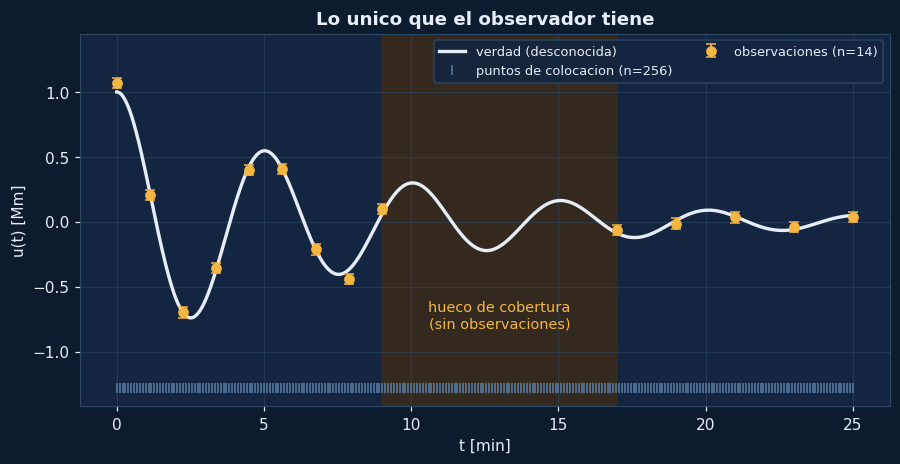

14 observaciones, sigma = 0.04 Mm
Hueco de 8 min = 1.6 periodos sin datos


In [5]:
sigma_ruido = 0.04                        # [Mm]
GAP = (9.0, 17.0)                         # hueco de cobertura [min]

t_data = np.concatenate([np.linspace(0.0, GAP[0], 9),
                         np.linspace(GAP[1], T_END, 5)])
u_data = solucion_exacta(t_data) + sigma_ruido*np.random.randn(t_data.size)

# Puntos de colocacion: cubren TODO el dominio, tambien el hueco.
t_col = np.linspace(0, T_END, 256)
mask_gap = (t_dense >= GAP[0]) & (t_dense <= GAP[1])

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.axvspan(*GAP, color="#3a2a1a", alpha=0.85, zorder=0)
ax.text(np.mean(GAP), -0.72, "hueco de cobertura\n(sin observaciones)",
        ha="center", va="center", color=C_DATOS, fontsize=9.5)
ax.plot(t_dense, u_exact, color=C_EXACTA, lw=2.2, label="verdad (desconocida)")
ax.errorbar(t_data, u_data, yerr=sigma_ruido, fmt="o", ms=6, color=C_DATOS,
            ecolor=C_DATOS, elinewidth=1.2, capsize=3, zorder=3,
            label=f"observaciones (n={t_data.size})")
ax.plot(t_col, np.full_like(t_col, -1.28), "|", color=C_COLOC, ms=6,
        label=f"puntos de colocacion (n={t_col.size})")
ax.set_xlabel("t [min]"); ax.set_ylabel("u(t) [Mm]")
ax.set_title("Lo unico que el observador tiene")
ax.set_ylim(-1.42, 1.45); ax.legend(loc="upper right", ncol=2, fontsize=8.5)
guardar(fig, "01_escenario_observacional")
plt.show()

print(f"{t_data.size} observaciones, sigma = {sigma_ruido} Mm")
print(f"Hueco de {GAP[1]-GAP[0]:.0f} min = {(GAP[1]-GAP[0])/P_obs:.1f} periodos sin datos")


## 5. La red y las dos pérdidas

### 5.1 Arquitectura

Un MLP $1\to32\to32\to32\to1$ con `tanh`. La activación suave no es una
preferencia estética: necesitamos que $\ddot u_\theta$ exista y sea continua, y
`ReLU` tiene segunda derivada nula casi en todas partes — con `ReLU` el residuo
de una EDO de segundo orden sería idénticamente cero salvo en un conjunto de
medida nula, y la pérdida física no informaría nada.

La red normaliza internamente $t\in[0,T]\to[-1,1]$. Como derivamos respecto al
tensor de tiempo **físico**, `autograd` propaga la regla de la cadena por esa
normalización y el residuo queda en unidades de min$^{-2}$, sin que tengamos que
corregir nada a mano.

### 5.2 Las dos pérdidas

$$
\mathcal{L}_{\rm datos}=\frac{1}{N}\sum_i\left[u_\theta(t_i)-u_i\right]^2,
\qquad
\mathcal{L}_{\rm física}=\frac{1}{N_c}\sum_j\left[\frac{r_\theta(t_j)}{\omega_0^2}\right]^2,
\qquad
\mathcal{L}_{\rm ci}=\left[u_\theta(0)-u_0\right]^2+\left[\frac{\dot u_\theta(0)-v_0}{\omega_0}\right]^2 .
$$

Nótese la **normalización del residuo por $\omega_0^2$** y de la velocidad inicial
por $\omega_0$. No es cosmética: sin ella, los tres términos tienen unidades y
magnitudes distintas, y el $\lambda$ que los equilibra depende de la escala
temporal elegida. Adimensionalizados, todos miden "error en Mm" y $\lambda$ se
vuelve interpretable. Esta es la primera línea de defensa contra la *patología de
gradientes* que menciona la presentación.

El único cambio entre los dos modelos es $\lambda_{\rm fis}$: vale $0$ para la
caja negra y $30$ para la PINN.

### 5.3 Mapa del código

Todo lo que sigue se apoya en siete funciones. Vale la pena tenerlas a mano,
porque las tareas de la §11 se resuelven combinándolas, sin escribir nada desde
cero:

| Función | Qué hace | Devuelve |
|---|---|---|
| `solucion_exacta(t)` | solución analítica, la verdad de referencia | `u(t)` |
| `rk4(f, t, y0)` | integrador clásico, referencia numérica | trayectoria |
| `generar_observaciones(...)` | serie sintética con ruido y hueco | `t, u, t_tensor, u_tensor` |
| `MLP()` | la red $u_\theta(t)$ | módulo de PyTorch |
| `perdidas(model, lam_fis, obs=...)` | las tres pérdidas | `(total, datos, física, ci)` |
| `entrenar(lam_fis, obs=...)` | Adam + L-BFGS, con instantáneas | `(modelo, historial, snaps, tiempo)` |
| `observables(model)` | audita el modelo | `u, v, a, residuo, E, dE, energía espuria` |
| `problema_inverso(obs=...)` | estima $\beta$ y $\omega_0$ | `(omega0, beta, traza)` |

Dos argumentos hacen todo el trabajo en las tareas:

- **`lam_fis`** decide cuánta física entra. Con `lam_fis=0` obtienes la caja
  negra; con `lam_fis=30`, la PINN.
- **`obs=(t_tensor, u_tensor)`** cambia las observaciones sin tocar nada más.
  Si no lo pasas, se usan los 14 puntos por defecto.


In [6]:
import torch
import torch.nn as nn

torch.manual_seed(7)
torch.set_default_dtype(torch.float32)
DEV = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| dispositivo:", DEV)

class MLP(nn.Module):
    # La red NO predice puntos sueltos: ES la solucion propuesta u_theta(t),
    # una funcion continua del tiempo cuyos parametros vamos a ajustar.
    def __init__(self, hidden=32, layers=3):
        super().__init__()
        # Entrada: 1 numero (el instante t). Salida: 1 numero (el desplazamiento).
        # En medio, capas densas con tanh. La activacion DEBE ser suave porque
        # despues le pediremos a esta funcion su segunda derivada.
        bloques = [nn.Linear(1, hidden), nn.Tanh()]
        for _ in range(layers - 1):
            bloques += [nn.Linear(hidden, hidden), nn.Tanh()]
        bloques += [nn.Linear(hidden, 1)]     # ultima capa sin activacion: salida libre
        self.net = nn.Sequential(*bloques)

    def forward(self, t):
        # t llega en minutos (0 a 25) y lo reescalamos a [-1, 1], que es donde
        # tanh trabaja bien. Hacerlo AQUI DENTRO, y no fuera, es lo que permite
        # que autograd trate la normalizacion como parte de la funcion y aplique
        # la regla de la cadena solo: las derivadas salen respecto al t fisico,
        # en 1/min, sin que tengamos que corregir ningun factor a mano.
        return self.net(2.0*t/T_END - 1.0)

def tensor(x, grad=False):
    # numpy -> tensor columna (N, 1), que es la forma que espera nn.Linear.
    # grad=True marca el tensor como "voy a derivar respecto a esto"; solo hace
    # falta en los tiempos donde evaluaremos la ecuacion diferencial.
    x = np.asarray(x, dtype=np.float32).reshape(-1, 1)
    return torch.tensor(x, device=DEV, requires_grad=grad)

def deriv(y, x):
    # Derivada dy/dx por diferenciacion automatica: recorre el grafo de
    # operaciones aplicando la regla de la cadena, asi que es exacta (no es una
    # diferencia finita, no hay error de truncamiento).
    #   torch.ones_like(y) -> autograd calcula productos vector-jacobiano; con
    #                         un vector de unos obtenemos la derivada de cada
    #                         salida respecto a su propia entrada.
    #   create_graph=True  -> conserva el grafo DE LA DERIVADA. Ese es el truco
    #                         que nos deja derivar el resultado otra vez y
    #                         obtener la segunda derivada.
    return torch.autograd.grad(y, x, torch.ones_like(y), create_graph=True)[0]

# Tensores fijos del problema. Los de datos no necesitan gradiente (no derivamos
# respecto a ellos); los de colocacion e inicial si, porque ahi evaluamos la EDO.
t_data_t = tensor(t_data)
u_data_t = tensor(u_data)
t_col_t  = tensor(t_col, grad=True)
t_ini_t  = tensor([0.0], grad=True)

def perdidas(model, lam_fis, lam_ci=20.0, obs=None):
    # El corazon de la PINN: convierte "la red debe obedecer la fisica" en un
    # numero que un optimizador puede minimizar.
    # Devuelve (total, datos, fisica, condiciones iniciales).
    # obs=(t_tensor, u_tensor) permite entrenar con OTRAS observaciones sin tocar
    # nada mas: es el gancho que usan los miniproyectos de la seccion 11.
    t_obs, u_obs = obs if obs is not None else (t_data_t, u_data_t)

    # (1) DATOS -- la red debe pasar cerca de lo observado.
    #     Se evalua SOLO en los instantes donde hay medicion.
    l_dat = torch.mean((model(t_obs) - u_obs)**2)

    if lam_fis > 0:
        # (2) FISICA -- aqui la PINN deja de ser una red corriente.
        #     Evaluamos la red en los puntos de colocacion: instantes repartidos
        #     por TODO el dominio que no necesitan ningun dato, incluido el hueco
        #     de cobertura. Es asi como la fisica rellena lo que no se observo.
        u_c = model(t_col_t)
        du  = deriv(u_c, t_col_t)      # velocidad     du/dt
        d2u = deriv(du,  t_col_t)      # aceleracion   d2u/dt2  (derivamos otra vez)

        #     Metemos esas derivadas en la ecuacion de movimiento. Si la red
        #     resolviera la EDO, r seria cero en todos los puntos: r mide cuanto
        #     la incumple. Dividimos por omega0^2 para que r quede en las mismas
        #     unidades que u, y asi lam_fis no dependa de la escala de tiempo.
        r = (d2u + 2*beta*du + omega0**2*u_c)/omega0**2
        l_fis = torch.mean(r**2)

        # (3) CONDICIONES INICIALES -- la EDO tiene infinitas soluciones y
        #     u(0), u'(0) eligen una. Sin este termino la red puede cumplir la
        #     fisica con la amplitud o la fase equivocadas.
        u_i  = model(t_ini_t)
        du_i = deriv(u_i, t_ini_t)
        l_ci = (u_i - u0).pow(2).mean() + ((du_i - v0)/omega0).pow(2).mean()
    else:
        # lam_fis = 0 -> modelo CAJA NEGRA: ni ecuacion ni condiciones iniciales.
        # Todo el bloque de arriba simplemente no se ejecuta.
        l_fis = torch.zeros((), device=DEV)
        l_ci  = torch.zeros((), device=DEV)

    # Suma ponderada: esto es lo unico que el optimizador llega a ver.
    return l_dat + lam_fis*l_fis + lam_ci*l_ci, l_dat, l_fis, l_ci

def generar_observaciones(gap=None, n_antes=9, n_despues=5, sigma=None,
                          seed=7, solucion=None):
    # Construye una serie observada sintetica: pocos puntos, ruido y un hueco.
    # Devuelve (t, u, t_tensor, u_tensor) listos para pasar como obs=(...).
    gap = GAP if gap is None else gap
    sigma = sigma_ruido if sigma is None else sigma
    solucion = solucion_exacta if solucion is None else solucion
    rng = np.random.default_rng(seed)
    t = np.concatenate([np.linspace(0.0, gap[0], n_antes),
                        np.linspace(gap[1], T_END, n_despues)])
    u = solucion(t) + sigma*rng.standard_normal(t.size)
    return t, u, tensor(t), tensor(u)


PyTorch 2.13.0+cpu | dispositivo: cpu


## 6. Entrenamiento: Adam y luego L-BFGS

Un detalle práctico que casi nunca aparece en los tutoriales y que decide si una
PINN funciona: **Adam solo no basta**. Adam es robusto y encuentra rápido la
cuenca correcta, pero se estanca en errores de $\sim10^{-2}$. L-BFGS, un método
cuasi-Newton que usa curvatura, refina esa solución dos o tres órdenes de
magnitud más. La receta estándar en la literatura de PINNs es exactamente esta
secuencia: **Adam para explorar, L-BFGS para converger**.

Ejecutamos L-BFGS en bloques de 100 iteraciones para poder tomar instantáneas del
modelo y animar el entrenamiento en §8.

> Ambos modelos reciben **idéntico presupuesto**: 6000 pasos de Adam con
> *cosine annealing* + 2000 iteraciones de L-BFGS. Cualquier diferencia en el
> resultado es atribuible a la pérdida, no al optimizador.


In [7]:
def entrenar(lam_fis, epochs_adam=6000, lr=5e-3, bloques_lbfgs=20,
             iter_lbfgs=100, cada=100, seed=7, etiqueta="", obs=None,
             lam_ci=20.0):
    # Ajusta los pesos de la red minimizando perdidas(). Guarda instantaneas del
    # modelo por el camino para poder animar el entrenamiento en la seccion 8.
    torch.manual_seed(seed)          # misma inicializacion para ambos modelos
    model = MLP().to(DEV)

    t_snap = tensor(t_dense, grad=True)
    snaps, hist = [], []

    def instantanea(fase, paso):
        # Foto del estado actual de la red: u(t) y su velocidad, en toda la
        # ventana temporal. detach() la saca del grafo (es solo para graficar).
        u = model(t_snap)
        v = deriv(u, t_snap)
        snaps.append(dict(fase=fase, paso=paso,
                          u=u.detach().cpu().numpy().ravel(),
                          v=v.detach().cpu().numpy().ravel()))

    instantanea("adam", 0)           # estado antes de entrenar nada

    # --- FASE 1: Adam. Robusto y barato; encuentra rapido la cuenca correcta,
    #     pero se estanca alrededor de 1e-2. El scheduler baja el paso poco a
    #     poco (cosine annealing) para afinar hacia el final.
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs_adam, eta_min=lr/50)
    t0 = time.perf_counter()
    for ep in range(1, epochs_adam + 1):
        opt.zero_grad()                                   # borra gradientes previos
        loss, l_dat, l_fis, l_ci = perdidas(model, lam_fis, lam_ci=lam_ci, obs=obs)
        loss.backward()                                   # gradiente respecto a los pesos
        opt.step()                                        # un paso de descenso
        sch.step()                                        # actualiza el learning rate
        if ep % cada == 0:
            instantanea("adam", ep)
        if ep % 500 == 0:
            hist.append([ep, loss.item(), l_dat.item(),
                         l_fis.detach().item(), l_ci.detach().item()])

    # --- FASE 2: L-BFGS. Metodo cuasi-Newton: aproxima la curvatura de la
    #     perdida y por eso refina la solucion de Adam dos o tres ordenes de
    #     magnitud mas. Es la mitad que suele faltar en los tutoriales de PINNs.
    lbfgs = torch.optim.LBFGS(model.parameters(), max_iter=iter_lbfgs,
                              history_size=60, tolerance_grad=1e-12,
                              tolerance_change=1e-14, line_search_fn="strong_wolfe")

    # L-BFGS reevalua la perdida varias veces por iteracion (busqueda de linea),
    # asi que hay que darle una funcion que la recalcule, no un valor ya hecho.
    def closure():
        lbfgs.zero_grad()
        loss, *_ = perdidas(model, lam_fis, lam_ci=lam_ci, obs=obs)
        loss.backward()
        return loss

    # Lo corremos en bloques para poder sacar instantaneas entre medias.
    for b in range(1, bloques_lbfgs + 1):
        lbfgs.step(closure)
        instantanea("lbfgs", b*iter_lbfgs)
        if b % 5 == 0:
            loss, l_dat, l_fis, l_ci = perdidas(model, lam_fis, lam_ci=lam_ci, obs=obs)
            hist.append([epochs_adam + b*iter_lbfgs, loss.item(), l_dat.item(),
                         l_fis.detach().item(), l_ci.detach().item()])

    dt = time.perf_counter() - t0
    loss, l_dat, l_fis, l_ci = perdidas(model, lam_fis, lam_ci=lam_ci, obs=obs)
    print(f"[{etiqueta:11s}] {dt:5.1f} s | total {loss.item():.3e} | "
          f"datos {l_dat.item():.3e} | fisica {l_fis.detach().item():.3e}")
    return model, np.array(hist), snaps, dt

LAMBDA_FIS = 30.0

modelo_negra, hist_negra, snaps_negra, tiempo_negra = entrenar(
    lam_fis=0.0, etiqueta="caja negra")
modelo_pinn,  hist_pinn,  snaps_pinn,  tiempo_pinn = entrenar(
    lam_fis=LAMBDA_FIS, etiqueta="PINN")


[caja negra ]   7.0 s | total 2.686e-13 | datos 2.686e-13 | fisica 0.000e+00


[PINN       ]  33.2 s | total 1.232e-03 | datos 9.111e-04 | fisica 1.066e-05


Fíjate en la pérdida de datos final de cada modelo antes de seguir.

La caja negra la lleva a $\sim10^{-13}$: pasa **exactamente** por los 14 puntos,
incluido su ruido. La PINN se queda en $\sim10^{-3}$, que es aproximadamente
$\sigma^2=1.6\times10^{-3}$, la varianza del ruido.

Esa "peor" pérdida de datos es en realidad el comportamiento correcto: la PINN
no puede pasar por el ruido porque la física se lo impide, así que se detiene
justo en el nivel del error de medición. Ajustar los datos mejor que su propia
barra de error es sobreajuste, no precisión.


In [8]:
def observables(model):
    # Audita un modelo ya entrenado. Nada de lo que se calcula aqui se uso
    # durante el entrenamiento de la caja negra, asi que sirve de juez imparcial.
    # Volvemos a derivar la red para obtener velocidad y aceleracion.
    t_t = tensor(t_dense, grad=True)
    u = model(t_t)
    v = deriv(u, t_t)                 # velocidad
    a = deriv(v, t_t)                 # aceleracion
    u = u.detach().cpu().numpy().ravel()
    v = v.detach().cpu().numpy().ravel()
    a = a.detach().cpu().numpy().ravel()

    residuo = a + 2*beta*v + omega0**2*u   # cuanto incumple la ecuacion (0 = perfecta)
    E = energia(u, v)                      # energia especifica del modelo
    dE = np.gradient(E, t_dense)           # su tasa de cambio, por diferencias finitas
    viol = dE + 2*beta*v**2                # ley de disipacion: deberia dar 0.
                                           # Si sale > 0, el modelo esta CREANDO energia.
    integrar = getattr(np, "trapezoid", None) or np.trapz   # numpy >= 2.0 / anterior
    E_espuria = integrar(np.clip(viol, 0, None), t_dense)/E_exact[0]
    return dict(u=u, v=v, a=a, residuo=residuo, E=E, dE=dE,
                viol=viol, E_espuria=E_espuria)

obs_negra = observables(modelo_negra)
obs_pinn  = observables(modelo_pinn)

def metricas(obs, nombre):
    u, v = obs["u"], obs["v"]
    return {
        "modelo": nombre,
        "RMSE u [Mm]": np.sqrt(np.mean((u - u_exact)**2)),
        "RMSE u en el hueco [Mm]": np.sqrt(np.mean((u[mask_gap] - u_exact[mask_gap])**2)),
        "RMSE v [Mm/min]": np.sqrt(np.mean((v - v_exact)**2)),
        "RMS residuo EDO": np.sqrt(np.mean(obs["residuo"]**2)),
        "max dE/dt (debe ser <=0)": np.max(obs["dE"]),
        "energia espuria / E(0)": obs["E_espuria"],
    }

import pandas as pd
tabla = pd.DataFrame([metricas(obs_negra, "caja negra"),
                      metricas(obs_pinn, "PINN")]).set_index("modelo").T
pd.set_option("display.float_format", lambda x: f"{x:.4g}")
tabla


modelo,caja negra,PINN
RMSE u [Mm],0.1504,0.004922
RMSE u en el hueco [Mm],0.2603,0.002908
RMSE v [Mm/min],0.1154,0.00617
RMS residuo EDO,0.2103,0.005143
max dE/dt (debe ser <=0),0.09462,0.0001268
energia espuria / E(0),0.4347,0.01336


Lee la tabla de abajo hacia arriba, porque el orden importa:

- **energía espuria** — la caja negra fabrica una fracción apreciable de $E(0)$
  de la nada. La PINN, prácticamente cero. Este es el veredicto físico.
- **max $\dot E$** — debería ser $\le0$ siempre. La caja negra lo viola con
  holgura.
- **RMS del residuo** — la caja negra incumple la ecuación de movimiento por uno
  o dos órdenes de magnitud más.
- **RMSE en el hueco** — donde no hay datos, la caja negra se descarrila; la PINN
  mantiene la precisión porque ahí los puntos de colocación siguen imponiendo la
  física.
- **RMSE de $v$** — nadie observó la velocidad. La PINN la reconstruye bien de
  todos modos: es un observable **oculto**, recuperado gracias a la ecuación.


## 7. Diagnóstico multi-observable

Un solo panel de $u(t)$ oculta el problema: a simple vista, las dos curvas
"pasan por los puntos". Hay que mirar las derivadas y las cantidades conservadas
(o disipadas) para ver quién está haciendo física y quién está dibujando.


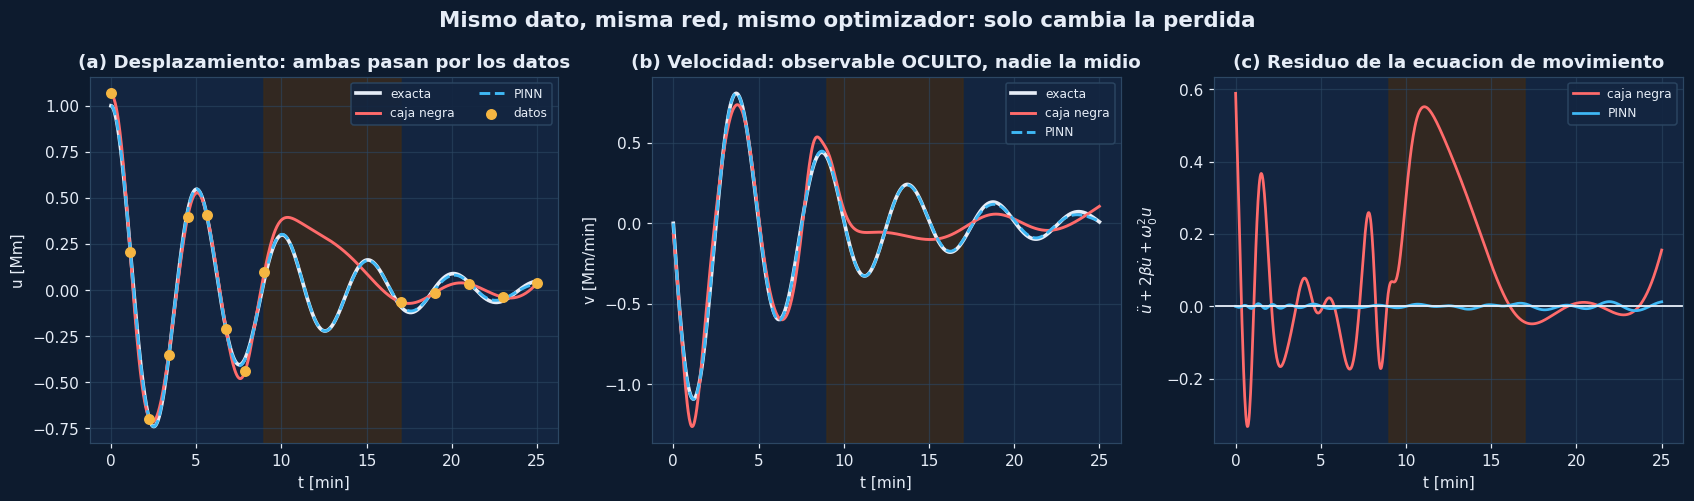

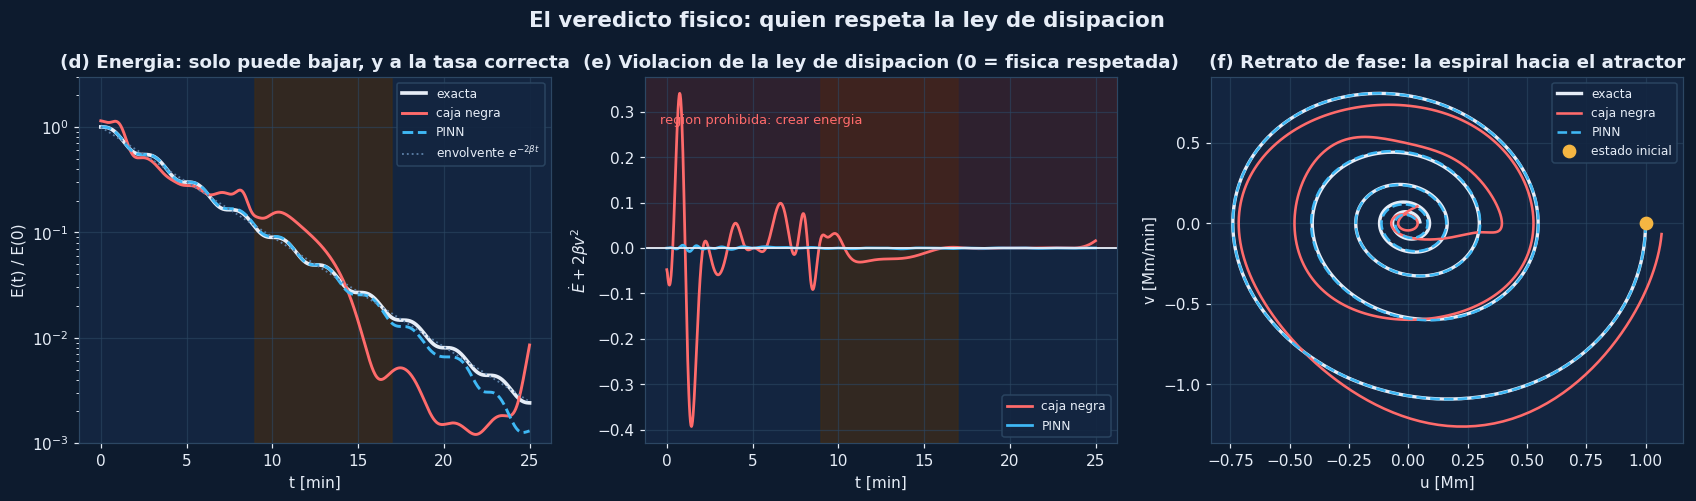

In [9]:
# ---------------------------------------------------------------
# Bloque 1: cinematica. Lo que se ve si solo miras la curva y sus derivadas.
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

# (a) desplazamiento
ax = axes[0]
ax.axvspan(*GAP, color="#3a2a1a", alpha=0.8, zorder=0)
ax.plot(t_dense, u_exact, color=C_EXACTA, lw=2.4, label="exacta")
ax.plot(t_dense, obs_negra["u"], color=C_NEGRA, lw=1.9, label="caja negra")
ax.plot(t_dense, obs_pinn["u"], color=C_PINN, lw=1.9, ls="--", label="PINN")
ax.scatter(t_data, u_data, s=38, color=C_DATOS, zorder=4, label="datos")
ax.set_xlabel("t [min]"); ax.set_ylabel("u [Mm]")
ax.set_title("(a) Desplazamiento: ambas pasan por los datos")
ax.legend(fontsize=8, ncol=2)

# (b) velocidad (nunca observada)
ax = axes[1]
ax.axvspan(*GAP, color="#3a2a1a", alpha=0.8, zorder=0)
ax.plot(t_dense, v_exact, color=C_EXACTA, lw=2.4, label="exacta")
ax.plot(t_dense, obs_negra["v"], color=C_NEGRA, lw=1.9, label="caja negra")
ax.plot(t_dense, obs_pinn["v"], color=C_PINN, lw=1.9, ls="--", label="PINN")
ax.set_xlabel("t [min]"); ax.set_ylabel("v [Mm/min]")
ax.set_title("(b) Velocidad: observable OCULTO, nadie la midio")
ax.legend(fontsize=8)

# (c) residuo de la EDO
ax = axes[2]
ax.axvspan(*GAP, color="#3a2a1a", alpha=0.8, zorder=0)
ax.plot(t_dense, obs_negra["residuo"], color=C_NEGRA, lw=1.8, label="caja negra")
ax.plot(t_dense, obs_pinn["residuo"], color=C_PINN, lw=1.8, label="PINN")
ax.axhline(0, color=C_EXACTA, lw=1.2)
ax.set_xlabel("t [min]"); ax.set_ylabel(r"$\ddot u+2\beta\dot u+\omega_0^2u$")
ax.set_title("(c) Residuo de la ecuacion de movimiento")
ax.legend(fontsize=8)

fig.suptitle("Mismo dato, misma red, mismo optimizador: solo cambia la perdida",
             fontsize=14, fontweight="bold")
fig.tight_layout()
guardar(fig, "02a_cinematica")
plt.show()

# ---------------------------------------------------------------
# Bloque 2: el veredicto fisico. Energia, disipacion y espacio de fase.
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6))

# (d) energia
ax = axes[0]
ax.axvspan(*GAP, color="#3a2a1a", alpha=0.8, zorder=0)
ax.plot(t_dense, E_exact/E_exact[0], color=C_EXACTA, lw=2.4, label="exacta")
ax.plot(t_dense, obs_negra["E"]/E_exact[0], color=C_NEGRA, lw=1.9, label="caja negra")
ax.plot(t_dense, obs_pinn["E"]/E_exact[0], color=C_PINN, lw=1.9, ls="--", label="PINN")
ax.plot(t_dense, np.exp(-2*beta*t_dense), color=C_COLOC, lw=1.2, ls=":",
        label=r"envolvente $e^{-2\beta t}$")
ax.set_yscale("log"); ax.set_ylim(1e-3, 3)
ax.set_xlabel("t [min]"); ax.set_ylabel("E(t) / E(0)")
ax.set_title("(d) Energia: solo puede bajar, y a la tasa correcta")
ax.legend(fontsize=8)

# (e) ley de disipacion
ax = axes[1]
ax.axvspan(*GAP, color="#3a2a1a", alpha=0.8, zorder=0)
ax.plot(t_dense, obs_negra["viol"], color=C_NEGRA, lw=1.8, label="caja negra")
ax.plot(t_dense, obs_pinn["viol"], color=C_PINN, lw=1.8, label="PINN")
ax.axhline(0, color=C_EXACTA, lw=1.2)
ax.autoscale(enable=False)     # fija los limites antes de sombrear
ax.axhspan(0, ax.get_ylim()[1], color="#4a1f1f", alpha=0.5, zorder=0)
ax.text(0.03, 0.9, "region prohibida: crear energia", color=C_NEGRA, fontsize=8.5,
        transform=ax.transAxes, va="top")
ax.set_xlabel("t [min]"); ax.set_ylabel(r"$\dot E+2\beta v^2$")
ax.set_title("(e) Violacion de la ley de disipacion (0 = fisica respetada)")
ax.legend(fontsize=8)

# (f) retrato de fase
ax = axes[2]
ax.plot(u_exact, v_exact, color=C_EXACTA, lw=2.2, label="exacta")
ax.plot(obs_negra["u"], obs_negra["v"], color=C_NEGRA, lw=1.7, label="caja negra")
ax.plot(obs_pinn["u"], obs_pinn["v"], color=C_PINN, lw=1.7, ls="--", label="PINN")
ax.plot([u0], [v0], "o", color=C_DATOS, ms=8, label="estado inicial")
ax.set_xlabel("u [Mm]"); ax.set_ylabel("v [Mm/min]")
ax.set_title("(f) Retrato de fase: la espiral hacia el atractor")
ax.legend(fontsize=8)

fig.suptitle("El veredicto fisico: quien respeta la ley de disipacion",
             fontsize=14, fontweight="bold")
fig.tight_layout()
guardar(fig, "02b_energia")
plt.show()


La caja negra falla de **dos maneras distintas**, y conviene separarlas porque
enseñan cosas diferentes.

**Falla 1 — donde SÍ hay datos ($t<9$ min): sobreajusta el ruido.** El panel (a)
se ve inofensivo, pero mira el (c) y el (e) en esa misma región: el residuo de la
caja negra oscila violentamente y la violación de la ley de disipación tiene sus
picos más altos justo ahí. La razón es geométrica: para pasar *exactamente* por
cada punto ruidoso, la curva necesita curvarse mucho entre punto y punto, y
curvatura es aceleración. Esas aceleraciones espurias son energía que el modelo
inyecta en el sistema. **Ajustar el ruido no es un pecado estadístico abstracto:
tiene una consecuencia física medible.**

**Falla 2 — donde NO hay datos: se aplana.** En el hueco, la caja negra pierde la
oscilación por completo; dibuja una joroba suave donde la verdad completa 1.6
ciclos. Sin datos y sin física, la red hace lo único que sabe hacer: interpolar
suavemente. Su energía (panel d) se queda en una meseta muy por encima del
decaimiento real, y en el extremo $t\to25$ se dispara hacia arriba al extrapolar.

El panel **(f)** muestra la consecuencia geométrica: la trayectoria verdadera es
una espiral que converge al origen. La caja negra la recorre desfasada y con la
espiral interior deformada — el atractor está mal reconstruido.

Si tomaras la curva de la caja negra y midieras sobre ella el período y el tiempo
de amortiguamiento para hacer sismología coronal, obtendrías números sin
significado físico. Ese es el costo real de ignorar la física.


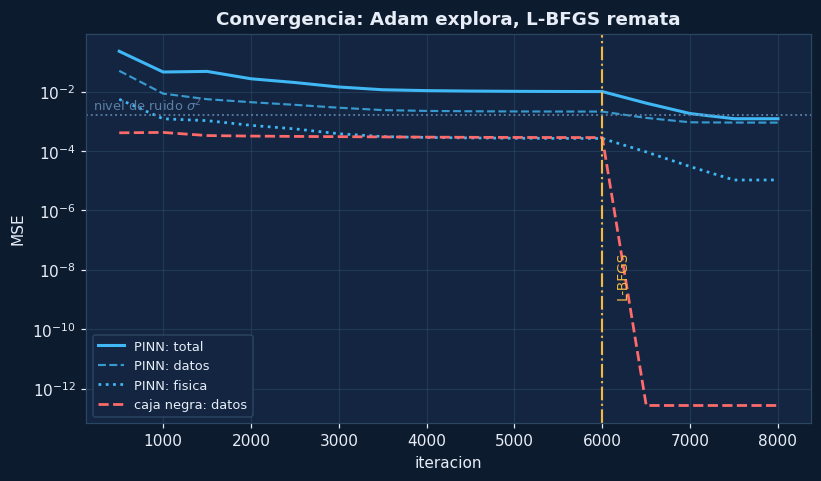

In [10]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.semilogy(hist_pinn[:, 0], hist_pinn[:, 1], "-", color=C_PINN, lw=2, label="PINN: total")
ax.semilogy(hist_pinn[:, 0], hist_pinn[:, 2], "--", color=C_PINN, lw=1.4, alpha=0.8,
            label="PINN: datos")
ax.semilogy(hist_pinn[:, 0], hist_pinn[:, 3], ":", color=C_PINN, lw=1.8, label="PINN: fisica")
ax.semilogy(hist_negra[:, 0], hist_negra[:, 2], "--", color=C_NEGRA, lw=1.8,
            label="caja negra: datos")
ax.axvline(6000, color=C_DATOS, lw=1.4, ls="-.")
ax.text(6150, 1e-9, "L-BFGS", color=C_DATOS, fontsize=9, rotation=90, va="bottom")
ax.axhline(sigma_ruido**2, color=C_COLOC, lw=1.2, ls=":")
ax.text(200, sigma_ruido**2*1.4, r"nivel de ruido $\sigma^2$", color=C_COLOC, fontsize=8.5)
ax.set_xlabel("iteracion"); ax.set_ylabel("MSE")
ax.set_title("Convergencia: Adam explora, L-BFGS remata")
ax.legend(fontsize=8.5, loc="lower left")
guardar(fig, "03_convergencia")
plt.show()


Dos lecturas de esta figura:

1. **El salto en la línea vertical** es el paso de Adam a L-BFGS. La pérdida
   física de la PINN cae varios órdenes de magnitud de golpe. Sin esa segunda
   fase, la PINN de este cuaderno sería visiblemente peor.
2. **La línea punteada horizontal** marca $\sigma^2$. La caja negra la atraviesa
   y sigue bajando hasta $10^{-13}$: está memorizando ruido. La PINN se detiene
   allí, que es justo donde debe.


## 8. Animación: cómo la física dobla la curva

Las instantáneas guardadas durante el entrenamiento permiten ver el proceso, no
solo el resultado. La animación muestra los tres observables simultáneamente:
desplazamiento, retrato de fase y energía.

Lo que hay que observar mientras corre:

- las dos redes arrancan igual (misma semilla, misma inicialización);
- ambas amortiguan primero la señal casi a cero y luego "descubren" la oscilación
  de izquierda a derecha, empezando por el primer ciclo;
- **en el hueco se separan**: la caja negra se queda plana ahí, porque nada la
  obliga a oscilar, mientras los puntos de colocación empujan a la PINN a
  continuar la oscilación a través del vacío;
- en el retrato de fase, la espiral de la PINN se cierra sobre la exacta y la de
  la caja negra queda desfasada;
- en el panel de energía, la curva roja se estanca por encima del decaimiento
  correcto en el tramo sin datos.


81 instantaneas por modelo


Animacion guardada en: figuras/04_entrenamiento.gif


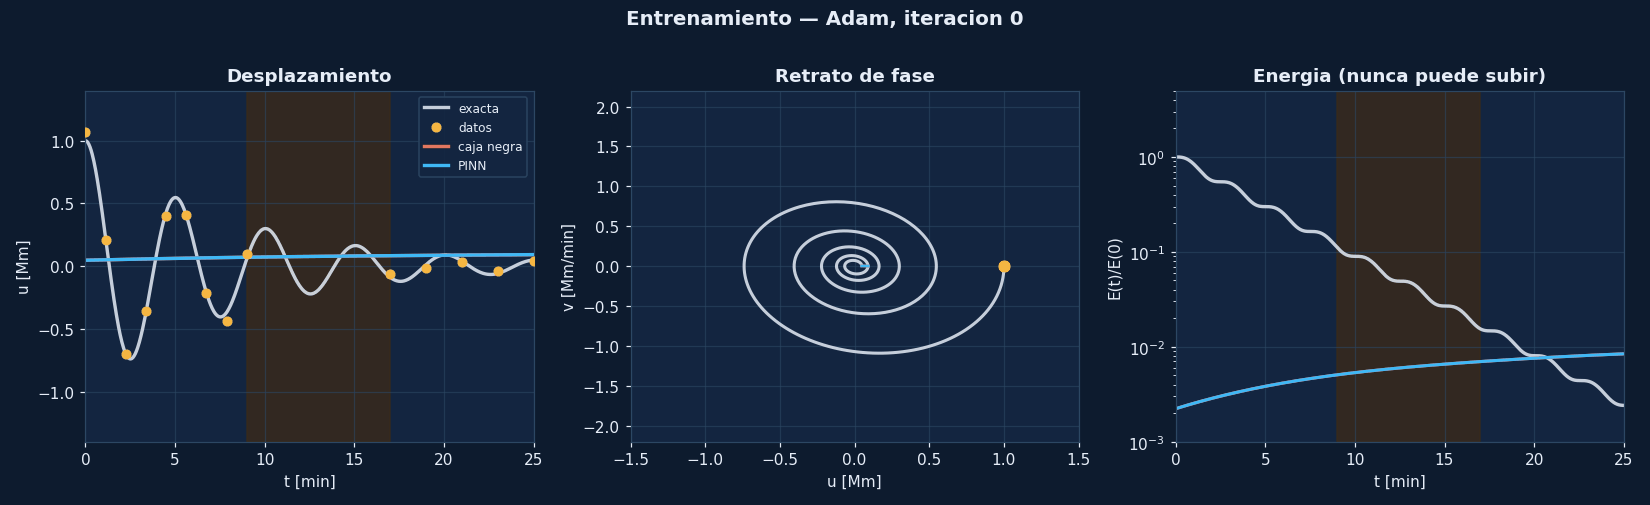

In [11]:
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import Image, display

n_frames = min(len(snaps_negra), len(snaps_pinn))
print(f"{n_frames} instantaneas por modelo")

fig_a, axs = plt.subplots(1, 3, figsize=(15, 4.6))

# panel 1: u(t)
ax1 = axs[0]
ax1.axvspan(*GAP, color="#3a2a1a", alpha=0.8, zorder=0)
ax1.plot(t_dense, u_exact, color=C_EXACTA, lw=2.2, alpha=0.85, label="exacta")
ax1.scatter(t_data, u_data, s=32, color=C_DATOS, zorder=4, label="datos")
ln_n1, = ax1.plot([], [], color=C_NEGRA, lw=2.2, label="caja negra")
ln_p1, = ax1.plot([], [], color=C_PINN, lw=2.2, label="PINN")
ax1.set_xlim(0, T_END); ax1.set_ylim(-1.4, 1.4)
ax1.set_xlabel("t [min]"); ax1.set_ylabel("u [Mm]")
ax1.set_title("Desplazamiento"); ax1.legend(fontsize=8, loc="upper right")

# panel 2: retrato de fase
ax2 = axs[1]
ax2.plot(u_exact, v_exact, color=C_EXACTA, lw=2.0, alpha=0.85, label="exacta")
ln_n2, = ax2.plot([], [], color=C_NEGRA, lw=1.8)
ln_p2, = ax2.plot([], [], color=C_PINN, lw=1.8)
ax2.plot([u0], [v0], "o", color=C_DATOS, ms=7)
ax2.set_xlim(-1.5, 1.5); ax2.set_ylim(-2.2, 2.2)
ax2.set_xlabel("u [Mm]"); ax2.set_ylabel("v [Mm/min]")
ax2.set_title("Retrato de fase")

# panel 3: energia
ax3 = axs[2]
ax3.axvspan(*GAP, color="#3a2a1a", alpha=0.8, zorder=0)
ax3.plot(t_dense, E_exact/E_exact[0], color=C_EXACTA, lw=2.2, alpha=0.85, label="exacta")
ln_n3, = ax3.plot([], [], color=C_NEGRA, lw=2.0)
ln_p3, = ax3.plot([], [], color=C_PINN, lw=2.0)
ax3.set_yscale("log"); ax3.set_xlim(0, T_END); ax3.set_ylim(1e-3, 5)
ax3.set_xlabel("t [min]"); ax3.set_ylabel("E(t)/E(0)")
ax3.set_title("Energia (nunca puede subir)")

titulo = fig_a.suptitle("", fontsize=13, fontweight="bold")
fig_a.tight_layout(rect=[0, 0, 1, 0.93])

def frame(k):
    sn, sp = snaps_negra[k], snaps_pinn[k]
    ln_n1.set_data(t_dense, sn["u"]); ln_p1.set_data(t_dense, sp["u"])
    ln_n2.set_data(sn["u"], sn["v"]); ln_p2.set_data(sp["u"], sp["v"])
    En = energia(sn["u"], sn["v"])/E_exact[0]
    Ep = energia(sp["u"], sp["v"])/E_exact[0]
    ln_n3.set_data(t_dense, En); ln_p3.set_data(t_dense, Ep)
    fase = "Adam" if sn["fase"] == "adam" else "L-BFGS"
    titulo.set_text(f"Entrenamiento — {fase}, iteracion {sn['paso']}")
    return ln_n1, ln_p1, ln_n2, ln_p2, ln_n3, ln_p3, titulo

anim = FuncAnimation(fig_a, frame, frames=n_frames, interval=140, blit=False)
gif = FIGDIR / "04_entrenamiento.gif"
anim.save(gif, writer=PillowWriter(fps=8))
plt.close(fig_a)

print("Animacion guardada en:", gif)
display(Image(filename=str(gif)))


## 9. El caso donde la PINN gana: el problema inverso

Todo lo anterior asumió que conocíamos $\beta$ y $\omega_0$. En una observación
real es exactamente al revés: **medimos $u(t)$ precisamente para averiguar esos
parámetros**, porque de ellos se deduce la física del lazo.

Aquí es donde una PINN hace algo que un integrador clásico no hace de forma
natural. Basta declarar los parámetros como tensores entrenables y optimizarlos
junto con los pesos:

$$
\min_{\theta,\ \beta,\ \omega_0}\ \
\mathcal{L}_{\rm datos}(\theta)
+\lambda_{\rm fis}\,\mathcal{L}_{\rm física}(\theta,\beta,\omega_0).
$$

El mismo bucle de entrenamiento resuelve simultáneamente el ajuste y la
estimación. No hay que integrar la EDO miles de veces con parámetros distintos,
como haría un ajuste por mínimos cuadrados sobre RK4.

Parametrizamos $\beta=e^{\,b}$ y $\omega_0=e^{\,w}$ para garantizar positividad, y
partimos de valores **deliberadamente equivocados** ($P=3.5$ min en vez de 5,
$\beta=0.35$ en vez de $0.12$) para comprobar que la convergencia no depende de
adivinar bien.


In [12]:
def problema_inverso(seed=7, epochs_adam=6000, lr=5e-3, lam_fis=1.0,
                     bloques_lbfgs=20, P_inicial=3.5, beta_inicial=0.35,
                     obs=None):
    torch.manual_seed(seed)
    model = MLP().to(DEV)
    t_obs, u_obs = obs if obs is not None else (t_data_t, u_data_t)

    log_w = torch.tensor(float(np.log(2*np.pi/P_inicial)), device=DEV, requires_grad=True)
    log_b = torch.tensor(float(np.log(beta_inicial)),      device=DEV, requires_grad=True)
    params = list(model.parameters()) + [log_w, log_b]

    def loss_fn():
        w, b = torch.exp(log_w), torch.exp(log_b)
        l_dat = torch.mean((model(t_obs) - u_obs)**2)
        u_c = model(t_col_t)
        du  = deriv(u_c, t_col_t)
        d2u = deriv(du,  t_col_t)
        r = (d2u + 2*b*du + w**2*u_c)/omega0**2
        return l_dat + lam_fis*torch.mean(r**2)

    traza = []
    opt = torch.optim.Adam(params, lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, epochs_adam, eta_min=lr/50)
    for ep in range(epochs_adam + 1):
        opt.zero_grad(); l = loss_fn(); l.backward(); opt.step(); sch.step()
        if ep % 100 == 0:
            traza.append([ep, torch.exp(log_w).item(), torch.exp(log_b).item()])

    lbfgs = torch.optim.LBFGS(params, max_iter=100, history_size=60,
                              tolerance_grad=1e-12, tolerance_change=1e-14,
                              line_search_fn="strong_wolfe")
    def closure():
        lbfgs.zero_grad(); l = loss_fn(); l.backward(); return l
    for b_i in range(bloques_lbfgs):
        lbfgs.step(closure)
        traza.append([epochs_adam + (b_i+1)*100,
                      torch.exp(log_w).item(), torch.exp(log_b).item()])

    return (torch.exp(log_w).item(), torch.exp(log_b).item(),
            np.array(traza), model)

# Varias semillas: un solo entrenamiento no es una medicion, es una anecdota.
SEMILLAS = [7, 11, 23]
resultados, trazas = [], []
for s in SEMILLAS:
    w_est, b_est, traza, _ = problema_inverso(seed=s)
    resultados.append((w_est, b_est)); trazas.append(traza)
    print(f"semilla {s:3d}:  omega_0 = {w_est:.4f} ({100*(w_est-omega0)/omega0:+.1f} %)   "
          f"beta = {b_est:.4f} ({100*(b_est-beta)/beta:+.1f} %)")

resultados = np.array(resultados)
w_m, w_s = resultados[:, 0].mean(), resultados[:, 0].std()
b_m, b_s = resultados[:, 1].mean(), resultados[:, 1].std()
print(f"\nomega_0 = {w_m:.4f} +/- {w_s:.4f}   (verdadero {omega0:.4f})")
print(f"beta    = {b_m:.4f} +/- {b_s:.4f}   (verdadero {beta:.4f})")


semilla   7:  omega_0 = 1.2460 (-0.8 %)   beta = 0.1264 (+5.3 %)


semilla  11:  omega_0 = 1.2484 (-0.7 %)   beta = 0.1274 (+6.1 %)


semilla  23:  omega_0 = 1.2456 (-0.9 %)   beta = 0.1254 (+4.5 %)

omega_0 = 1.2467 +/- 0.0012   (verdadero 1.2566)
beta    = 0.1264 +/- 0.0008   (verdadero 0.1200)


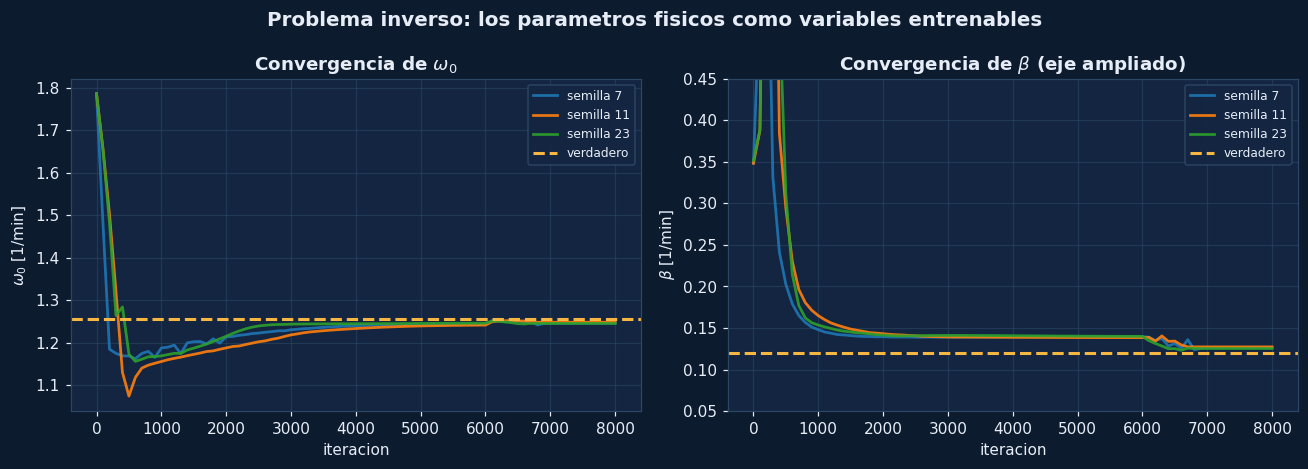

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))

for tr, s in zip(trazas, SEMILLAS):
    axes[0].plot(tr[:, 0], tr[:, 1], lw=1.8, alpha=0.9, label=f"semilla {s}")
    axes[1].plot(tr[:, 0], tr[:, 2], lw=1.8, alpha=0.9, label=f"semilla {s}")

axes[0].axhline(omega0, color=C_DATOS, lw=2, ls="--", label="verdadero")
axes[0].set_ylabel(r"$\omega_0$ [1/min]"); axes[0].set_title(r"Convergencia de $\omega_0$")
axes[1].axhline(beta, color=C_DATOS, lw=2, ls="--", label="verdadero")
axes[1].set_ylabel(r"$\beta$ [1/min]")
axes[1].set_title(r"Convergencia de $\beta$ (eje ampliado)")
axes[1].set_ylim(0.05, 0.45)   # el transitorio inicial se sale del eje a proposito
for ax in axes:
    ax.set_xlabel("iteracion"); ax.legend(fontsize=8)
fig.suptitle("Problema inverso: los parametros fisicos como variables entrenables",
             fontsize=13, fontweight="bold")
fig.tight_layout()
guardar(fig, "05_problema_inverso")
plt.show()


Un resultado que conviene no maquillar: **$\omega_0$ se recupera con un error de
menos del 1 %, mientras que $\beta$ falla por bastante más**, con dispersión
apreciable entre semillas.

Eso no es un defecto del código; es física. El período está codificado en el
cruce por cero de la señal y muchos ciclos lo restringen fuertemente. El
amortiguamiento, en cambio, se lee de la envolvente de amplitud, que con ruido de
$0.04$ Mm y un hueco de 8 minutos está mucho peor determinada. **Exactamente la
misma jerarquía de incertidumbres aparece en la sismología coronal real**: los
períodos se miden bien, los tiempos de amortiguamiento son la fuente dominante de
error en los diagnósticos.

### 9.1 De los parámetros a la física del lazo

Con $P$ y $\tau$ estimados podemos hacer sismología coronal, que es todo el punto
del ejercicio.

**Campo magnético.** Para el modo kink de un tubo delgado de longitud $L$, la
velocidad kink es $c_k=2L/P$, y si el campo es aproximadamente uniforme,

$$
c_k=B\sqrt{\frac{2}{\mu_0(\rho_i+\rho_e)}}
\qquad\Longrightarrow\qquad
B=c_k\sqrt{\frac{\mu_0(\rho_i+\rho_e)}{2}} .
$$

**Estructura fina transversal.** Si el amortiguamiento se debe a absorción
resonante en una capa inhomogénea de ancho $l$ en un tubo de radio $a$, la teoría
de capa delgada da

$$
\frac{\tau}{P}=\frac{2}{\pi}\,\frac{a}{l}\,\frac{\zeta+1}{\zeta-1},
\qquad \zeta=\rho_i/\rho_e,
$$

de donde se despeja $l/a$: el grosor de la capa de transición del borde del lazo,
una escala de **cientos de kilómetros** que ningún telescopio actual resuelve
directamente, pero que la oscilación codifica.


In [14]:
# --- constantes y suposiciones del modelo de lazo
L_lazo = 100.0        # longitud del lazo, de pie a pie [Mm]
zeta   = 3.0          # contraste de densidad rho_i/rho_e
n_i    = 1.0e15       # densidad numerica interna [m^-3]
mu_0   = 4*np.pi*1e-7
m_p    = 1.6726e-27

rho_i = n_i*m_p
rho_e = rho_i/zeta

def sismologia(P_min, tau_min, etiqueta):
    c_k = 2*L_lazo*1e6/(P_min*60.0)                   # m/s
    B   = c_k*np.sqrt(mu_0*(rho_i + rho_e)/2)         # T
    tau_P = tau_min/P_min
    l_a = (2/np.pi)*((zeta + 1)/(zeta - 1))/tau_P
    print(f"{etiqueta}")
    print(f"   P = {P_min:.3f} min , tau = {tau_min:.3f} min , tau/P = {tau_P:.2f}")
    print(f"   c_k = {c_k/1e3:.0f} km/s")
    print(f"   B   = {B*1e4:.2f} G")
    print(f"   l/a = {l_a:.2f}   (ancho relativo de la capa inhomogenea)")
    print(f"   l   = {l_a*1.0:.2f} a  ->  {l_a*1000:.0f} km si a = 1 Mm")
    return B*1e4, l_a

print("Diagnostico con los parametros VERDADEROS")
B_true, la_true = sismologia(P_obs, tau_d, "  [verdad]")
print()
print("Diagnostico con lo que la PINN estimo desde 14 puntos ruidosos con hueco")
omega_d_est = np.sqrt(max(w_m**2 - b_m**2, 1e-12))
B_est, la_est = sismologia(2*np.pi/omega_d_est, 1/b_m, "  [PINN]")
print()
print(f"Error en B   : {100*abs(B_est-B_true)/B_true:.1f} %")
print(f"Error en l/a : {100*abs(la_est-la_true)/la_true:.1f} %")


Diagnostico con los parametros VERDADEROS
  [verdad]
   P = 5.023 min , tau = 8.333 min , tau/P = 1.66
   c_k = 664 km/s
   B   = 7.86 G
   l/a = 0.77   (ancho relativo de la capa inhomogenea)
   l   = 0.77 a  ->  767 km si a = 1 Mm

Diagnostico con lo que la PINN estimo desde 14 puntos ruidosos con hueco
  [PINN]
   P = 5.066 min , tau = 7.912 min , tau/P = 1.56
   c_k = 658 km/s
   B   = 7.79 G
   l/a = 0.82   (ancho relativo de la capa inhomogenea)
   l   = 0.82 a  ->  815 km si a = 1 Mm

Error en B   : 0.8 %
Error en l/a : 6.2 %


Este es el cierre del argumento del cuaderno. Partiendo de 14 medidas ruidosas de
una posición, con un hueco de cobertura de más de un período, y **sin conocer
ningún parámetro del sistema**, obtenemos una estimación del campo magnético
coronal a unos pocos gauss de la verdad y del ancho de la capa inhomogénea del
lazo.

El error en $B$ es pequeño porque hereda el de $P$, que está bien determinado. El
error en $l/a$ es mayor porque hereda el de $\tau$. Esa propagación de
incertidumbre es información útil: te dice **en qué observable invertir esfuerzo
instrumental** si quieres mejorar el diagnóstico.


## 10. Honestidad computacional: PINN vs RK4

Toca cerrar el círculo con la advertencia del §1.3. Comparemos los dos métodos en
el **problema directo**, que es donde mucha gente usa PINNs sin necesitarlo.


In [15]:
rmse_pinn_u = np.sqrt(np.mean((obs_pinn["u"] - u_exact)**2))
comparacion = pd.DataFrame({
    "RK4 (problema directo)": {
        "necesita conocer beta, omega_0": "si",
        "tiempo de computo": f"{1e3*t_rk4:.1f} ms",
        "error maximo en u [Mm]": f"{err_rk4:.2e}",
        "usa datos observados": "no",
        "tolera huecos y ruido": "no aplica",
        "estima parametros desconocidos": "no",
        "reconstruye variables ocultas": "no",
    },
    "PINN (asimilacion + inverso)": {
        "necesita conocer beta, omega_0": "no (los estima)",
        "tiempo de computo": f"{tiempo_pinn:.0f} s",
        "error maximo en u [Mm]": f"{np.max(np.abs(obs_pinn['u']-u_exact)):.2e}",
        "usa datos observados": "si",
        "tolera huecos y ruido": "si",
        "estima parametros desconocidos": "si",
        "reconstruye variables ocultas": "si",
    },
})
print(f"RK4 es ~{tiempo_pinn/t_rk4:,.0f}x mas rapido y ~{rmse_pinn_u/err_rk4:,.0f}x "
      f"mas preciso en el problema directo.\n")
comparacion


RK4 es ~1,641x mas rapido y ~63,669x mas preciso en el problema directo.



,RK4 (problema directo),PINN (asimilacion + inverso)
"necesita conocer beta, omega_0",si,no (los estima)
tiempo de computo,20.2 ms,33 s
error maximo en u [Mm],7.73e-08,1.41e-02
usa datos observados,no,si
tolera huecos y ruido,no aplica,si
estima parametros desconocidos,no,si
reconstruye variables ocultas,no,si


Las dos primeras filas son demoledoras para la PINN, y está bien que lo sean.
**Nadie debería resolver esta EDO con una red neuronal.**

Las cinco filas siguientes son donde la comparación se invierte, y no por un
margen: RK4 sencillamente **no puede** hacer esas cosas sin envolverse en un
esquema de optimización externo que lo llame miles de veces.

La conclusión operativa:

> Usa una PINN cuando el problema esté **mal planteado en el sentido clásico**:
> datos incompletos, parámetros desconocidos, variables no observadas,
> condiciones de frontera que faltan. Si el problema está bien planteado y solo
> hay que integrarlo, integra.

Y una advertencia final que se aplica a todo lo anterior: la PINN acertó porque
la ecuación que le impusimos **era la correcta**. Si el amortiguamiento real
fuera no lineal, o si hubiera un forzamiento que no modelamos, la red te
entregaría un ajuste bonito con parámetros sin sentido. La física en la pérdida
no es un seguro contra equivocarse de física.


## 11. Miniproyectos

Cuatro experimentos de **5 a 10 minutos**. La arquitectura ya está montada: la
función `experimento(...)` hace el recorrido completo —fabrica las
observaciones, entrena, audita el resultado y lo grafica— y lo único que hay que
hacer es **cambiarle parámetros y mirar qué pasa**.

```python
experimento("mi prueba", lam_fis=30, n_antes=4, sigma=0.04)
```

| Parámetro | Qué controla |
|---|---|
| `lam_fis` | cuánta física entra en la pérdida (`0` = caja negra) |
| `n_antes`, `n_despues` | cuántas observaciones hay a cada lado del hueco |
| `sigma` | ruido de medición, en Mm |
| `ancho_hueco` | cuántos minutos de cobertura se pierden |
| `verdad` | qué dinámica generó realmente los datos |

Y `comparar(...)` corre el mismo escenario dos veces, con y sin física, para
ponerlas lado a lado.

**Qué se entrega:** la celda ejecutada y **dos o tres frases** respondiendo la
pregunta. La pregunta pesa más que el código.

> **Una diferencia con las secciones anteriores.** Aquí entrenamos con
> `lam_ci=0`, es decir **sin regalarle la condición inicial** a la red. Es más
> realista —nadie conoce $u(0)$ y $\dot u(0)$ exactamente— y hace que los
> experimentos tengan algo que medir: con la condición inicial impuesta, la
> física sola ya determina la solución y quitar datos no cambia nada.
>
> El presupuesto de entrenamiento también es más corto, para que cada corrida
> tarde unos diez segundos. Los números salen algo peores que los de la §7.


In [17]:
CENTRO_HUECO = 13.0   # el hueco de cobertura se centra en este instante

def experimento(etiqueta, lam_fis=LAMBDA_FIS, ancho_hueco=8.0, sigma=None,
                n_antes=9, n_despues=5, verdad=None, seed=7, lam_ci=0.0,
                epochs_adam=1500, bloques_lbfgs=5, graficar=True):
    # Recorrido completo de un experimento, de los datos al diagnostico fisico.
    # No hay que escribir nada de entrenamiento: solo cambiar los parametros.
    verdad = solucion_exacta if verdad is None else verdad
    sigma = sigma_ruido if sigma is None else sigma

    # 1. fabricar las observaciones que tendria el observador
    gap = (CENTRO_HUECO - ancho_hueco/2, CENTRO_HUECO + ancho_hueco/2)
    t_obs, u_obs, t_obs_t, u_obs_t = generar_observaciones(
        gap=gap, n_antes=n_antes, n_despues=n_despues, sigma=sigma,
        seed=seed, solucion=verdad)

    # 2. entrenar la red con esas observaciones
    modelo, _, _, _ = entrenar(lam_fis=lam_fis, lam_ci=lam_ci, obs=(t_obs_t, u_obs_t),
                               epochs_adam=epochs_adam, bloques_lbfgs=bloques_lbfgs,
                               seed=seed, etiqueta=etiqueta)

    # 3. auditar: error contra la verdad, y respeto de la fisica
    o = observables(modelo)
    u_ref = verdad(t_dense)
    # misfit: cuanto se aleja el ajuste de los datos observados. Comparado con
    # sigma es el test clasico de bondad de ajuste: si el modelo no consigue
    # bajar al nivel de ruido del instrumento, algo no cuadra.
    u_en_datos = np.interp(t_obs, t_dense, o["u"])
    met = {
        "experimento": etiqueta,
        "n datos": int(t_obs.size),
        "RMSE u [Mm]": float(np.sqrt(np.mean((o["u"] - u_ref)**2))),
        "misfit / sigma": float(np.sqrt(np.mean((u_en_datos - u_obs)**2))/sigma),
        "RMS residuo": float(np.sqrt(np.mean(o["residuo"]**2))),
        "energia espuria / E(0)": float(o["E_espuria"]),
    }

    # 4. graficar: la curva a la izquierda, el veredicto energetico a la derecha
    if graficar:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.0))
        if ancho_hueco > 0:
            for ax in (ax1, ax2):
                ax.axvspan(*gap, color="#3a2a1a", alpha=0.8, zorder=0)
        ax1.plot(t_dense, u_ref, color=C_EXACTA, lw=2.2, label="verdad")
        ax1.plot(t_dense, o["u"], color=C_PINN, lw=2.0, ls="--", label="modelo")
        ax1.scatter(t_obs, u_obs, s=34, color=C_DATOS, zorder=3, label="datos")
        ax1.set_xlabel("t [min]"); ax1.set_ylabel("u [Mm]")
        ax1.set_ylim(-1.6, 1.6)
        ax1.set_title(etiqueta); ax1.legend(fontsize=8)

        # la energia de referencia se calcula de la verdad de ESTE experimento,
        # que no siempre es la solucion lineal (ver miniproyecto 4)
        E_ref = energia(u_ref, np.gradient(u_ref, t_dense))
        ax2.plot(t_dense, E_ref/E_ref[0], color=C_EXACTA, lw=2.2, label="verdad")
        ax2.plot(t_dense, o["E"]/E_ref[0], color=C_PINN, lw=2.0, ls="--", label="modelo")
        ax2.set_yscale("log"); ax2.set_ylim(1e-4, 10)
        ax2.set_xlabel("t [min]"); ax2.set_ylabel("E(t)/E(0)")
        ax2.set_title(f"energia espuria = {100*met['energia espuria / E(0)']:.1f} % de E(0)")
        ax2.legend(fontsize=8)
        fig.tight_layout(); plt.show()

    return {**met, "modelo": modelo, "obs": (t_obs, u_obs), "diagnostico": o}

def comparar(etiqueta, **kw):
    # El mismo escenario con y sin fisica, para ponerlos lado a lado.
    return [experimento(f"{etiqueta} | caja negra", lam_fis=0.0, graficar=False, **kw),
            experimento(f"{etiqueta} | PINN",       lam_fis=LAMBDA_FIS, graficar=False, **kw)]

def tabla_de(resultados):
    # Junta varios experimentos en una tabla, dejando fuera modelos y arrays.
    cols = [k for k, v in resultados[0].items() if isinstance(v, (int, float, str))]
    return pd.DataFrame([{k: r[k] for k in cols} for r in resultados]).set_index("experimento")

print("Listo. Prueba:  experimento('mi primera prueba', lam_fis=30)")


Listo. Prueba:  experimento('mi primera prueba', lam_fis=30)


### Miniproyecto 1 — ¿Cuánta física conviene meter? (5 min)

Solo cambia `lam_fis`. Con 0 tienes la caja negra. Sube hasta un valor
desproporcionado y mira **la amplitud** de lo que sale, no solo el error.

**Pregunta:** con `lam_fis` gigantesco la red deja de hacer caso a los datos.
¿Hacia qué solución converge entonces? Fíjate en que esa solución **también
satisface la ecuación diferencial**: ¿por qué es una respuesta legítima para la
pérdida física y aun así inútil?


[lambda = 0 ]   1.9 s | total 3.151e-14 | datos 3.151e-14 | fisica 0.000e+00


[lambda = 1 ]   7.9 s | total 1.921e-03 | datos 1.201e-03 | fisica 7.198e-04


[lambda = 30]   9.3 s | total 5.489e-03 | datos 1.526e-03 | fisica 1.321e-04


[lambda = 30]   9.1 s | total 5.489e-03 | datos 1.526e-03 | fisica 1.321e-04


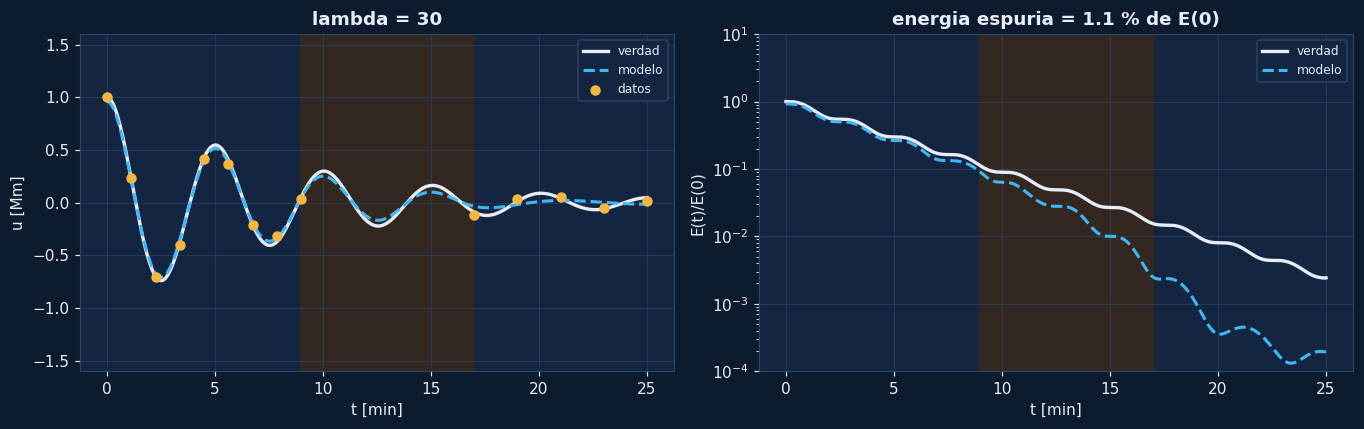

,n datos,RMSE u [Mm],misfit / sigma,RMS residuo,energia espuria / E(0)
experimento,,,,,
lambda = 0,14,0.5443,0.0008164,0.7688,2.856
lambda = 1,14,0.07593,0.8664,0.04242,0.0208
lambda = 30,14,0.04082,0.9766,0.01802,0.01077


In [18]:
# --- MINIPROYECTO 1 ------------------------------------------------
valores = [0.0, 1.0, 30.0]        # TODO: agrega un valor desproporcionado, p.ej. 3000

resultados = [experimento(f"lambda = {lam:g}", lam_fis=lam, graficar=False)
              for lam in valores]

# graficamos el ultimo para ver que forma tiene la solucion
experimento(f"lambda = {valores[-1]:g}", lam_fis=valores[-1])

tabla_de(resultados)


### Miniproyecto 2 — ¿Cuánto vale la ecuación, medido en datos? (10 min)

Ve quitando observaciones y compara los dos modelos en cada escalón. Empiezas con
14 puntos y bajas hasta 2.

**Pregunta:** la caja negra se desmorona; la PINN casi no se entera. ¿Qué
información aporta la EDO que los datos ya no tienen que aportar? Pista: la
ecuación es de segundo orden, así que su familia de soluciones tiene **dos**
parámetros libres (amplitud y fase). ¿Cuántos puntos bastarían, en principio,
para fijarlos?


In [19]:
# --- MINIPROYECTO 2 ------------------------------------------------
escalones = [(9, 5), (4, 2), (2, 2)]   # TODO: agrega el caso extremo (1, 1) = 2 datos

resultados = []
for n_a, n_d in escalones:
    resultados += comparar(f"{n_a + n_d} datos", n_antes=n_a, n_despues=n_d)

tabla_de(resultados)


[14 datos | caja negra]   2.0 s | total 3.151e-14 | datos 3.151e-14 | fisica 0.000e+00


[14 datos | PINN]   9.4 s | total 5.489e-03 | datos 1.526e-03 | fisica 1.321e-04


[6 datos | caja negra]   1.5 s | total 6.761e-16 | datos 6.761e-16 | fisica 0.000e+00


[6 datos | PINN]   9.2 s | total 5.758e-03 | datos 1.367e-03 | fisica 1.464e-04


[4 datos | caja negra]   1.5 s | total 0.000e+00 | datos 0.000e+00 | fisica 0.000e+00


[4 datos | PINN]   9.0 s | total 7.656e-03 | datos 1.793e-03 | fisica 1.954e-04


,n datos,RMSE u [Mm],misfit / sigma,RMS residuo,energia espuria / E(0)
experimento,,,,,
14 datos | caja negra,14,0.5443,0.0008164,0.7688,2.856
14 datos | PINN,14,0.04082,0.9766,0.01802,0.01077
6 datos | caja negra,6,0.2008,0.0001867,0.3139,0.9733
6 datos | PINN,6,0.04238,0.9242,0.01903,0.003342
4 datos | caja negra,4,0.4242,1.702e-05,0.5176,0.01027
4 datos | PINN,4,0.05181,1.059,0.02207,0.004835


### Miniproyecto 3 — ¿Y si el instrumento es peor? (5 min)

Ahora deja los datos fijos y sube el ruido: $\sigma$, $3\sigma$, $10\sigma$.

**Preguntas:**

1. El error de la PINN apenas se mueve, mientras el de la caja negra es varias
   veces mayor y su energía espuria es dos o tres órdenes de magnitud más alta.
   ¿Por qué el ruido afecta tanto menos a la PINN?
2. Fíjate en que el error de la caja negra **no crece de forma ordenada** con
   $\sigma$: da tumbos. Cambia `seed=8` y vuelve a correr. ¿Qué te dice esa
   inestabilidad sobre qué está aprendiendo realmente ese modelo?
3. Mira la columna `misfit / sigma`. La PINN se queda cerca de 1 y la caja negra
   baja mucho por debajo. ¿Por qué ajustar los datos *mejor* que su propia barra
   de error es una mala señal y no una buena?


In [20]:
# --- MINIPROYECTO 3 ------------------------------------------------
factores = [1, 3]                 # TODO: agrega un instrumento pesimo, factor 10

resultados = []
for f in factores:
    resultados += comparar(f"ruido x{f}", sigma=f*sigma_ruido)

tabla_de(resultados)


[ruido x1 | caja negra]   1.9 s | total 3.151e-14 | datos 3.151e-14 | fisica 0.000e+00


[ruido x1 | PINN]   8.8 s | total 5.489e-03 | datos 1.526e-03 | fisica 1.321e-04


[ruido x3 | caja negra]   2.3 s | total 3.365e-14 | datos 3.365e-14 | fisica 0.000e+00


[ruido x3 | PINN]   8.9 s | total 1.039e-02 | datos 5.692e-03 | fisica 1.565e-04


,n datos,RMSE u [Mm],misfit / sigma,RMS residuo,energia espuria / E(0)
experimento,,,,,
ruido x1 | caja negra,14,0.5443,0.0008164,0.7688,2.856
ruido x1 | PINN,14,0.04082,0.9766,0.01802,0.01077
ruido x3 | caja negra,14,0.1443,0.0002536,0.2469,0.6721
ruido x3 | PINN,14,0.04875,0.6287,0.01972,0.003102


### Miniproyecto 4 — Cuando la física impuesta es la equivocada (10 min)

El más importante de los cuatro. Generamos los datos con un amortiguamiento
**cuadrático** ($\gamma\dot u|\dot u|$, típico de arrastre turbulento) y
entrenamos imponiendo el modelo **lineal** de este cuaderno.

La red devolverá un ajuste de aspecto razonable y un $\beta$ perfectamente
presentable. No existe ningún $\beta$ verdadero con el que compararlo.

**Pregunta:** sin saber de antemano cómo se generaron los datos, ¿qué
diagnóstico te delataría que el modelo físico impuesto es el equivocado?

Antes de responder, mira las dos columnas de la tabla que imprime la celda:

- el **RMS del residuo** es prácticamente el mismo en los dos casos. Tiene
  sentido: el residuo solo mide si la red obedece la ecuación que *tú* le
  impusiste, y eso lo consigue siempre. **El residuo no puede delatar una física
  equivocada.**
- el **misfit / sigma** sí cambia. Con la física correcta el ajuste baja hasta el
  nivel de ruido del instrumento ($\approx1$); con la física equivocada se
  atasca dos o tres veces por encima, porque ninguna solución de la ecuación
  lineal puede pasar por esos puntos.

Ese cociente es el test clásico de bondad de ajuste. La conclusión práctica: **un
modelo que no consigue bajar al nivel de ruido de tus datos te está diciendo que
el modelo está mal, no los datos.**


[datos no lineales, fisica lineal]   9.2 s | total 2.112e-02 | datos 1.352e-02 | fisica 2.536e-04


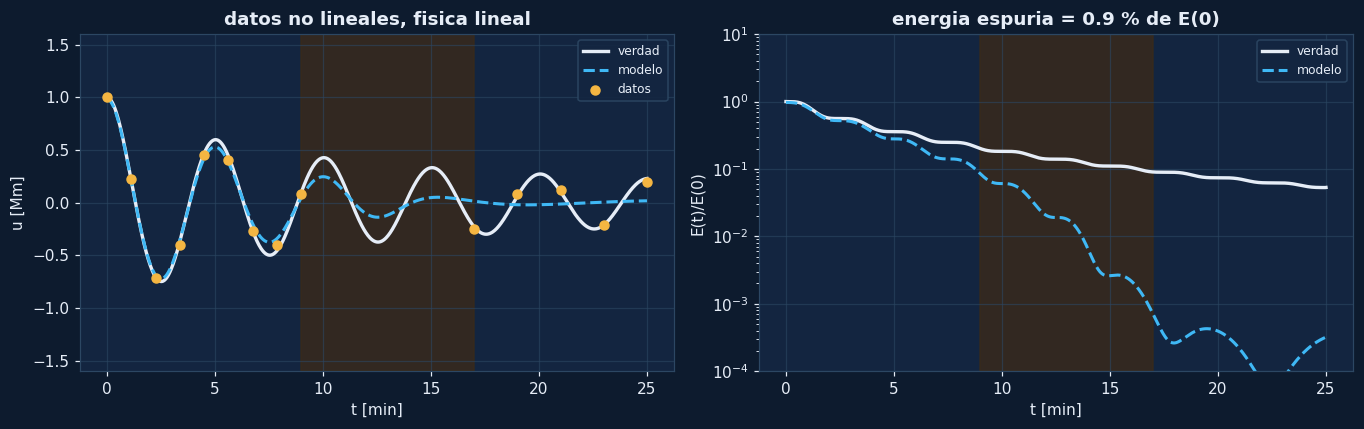

[datos lineales, fisica correcta]   9.2 s | total 5.489e-03 | datos 1.526e-03 | fisica 1.321e-04
                                  misfit / sigma  RMS residuo
experimento                                                  
datos lineales, fisica correcta           0.9766      0.01802
datos no lineales, fisica lineal           2.907      0.02512

El residuo apenas distingue los dos casos; el misfit si.



beta estimado = 0.1312  <- respetable, y sin significado fisico


In [21]:
# --- MINIPROYECTO 4 ------------------------------------------------
gamma = 0.25                      # TODO: prueba tambien 0.05 (casi lineal) y 0.8

def rhs_nolineal(t, y):
    u, v = y
    return np.array([v, -gamma*v*abs(v) - omega0**2*u], dtype=float)

# la "verdad" ahora es no lineal: la resolvemos con RK4 y la interpolamos
y_nl = rk4(rhs_nolineal, t_dense, [u0, v0])
verdad_nolineal = lambda t: np.interp(t, t_dense, y_nl[:, 0])

# entrenamos con la fisica LINEAL, que es la equivocada
malo = experimento("datos no lineales, fisica lineal", verdad=verdad_nolineal)
bueno = experimento("datos lineales, fisica correcta", graficar=False)

print(tabla_de([bueno, malo])[["misfit / sigma", "RMS residuo"]])
print("\nEl residuo apenas distingue los dos casos; el misfit si.")

# y ahora le pedimos que estime beta, un parametro que en estos datos no existe
w_est, b_est, _, _ = problema_inverso(
    obs=(tensor(malo["obs"][0]), tensor(malo["obs"][1])),
    epochs_adam=3000, bloques_lbfgs=10)
print(f"\nbeta estimado = {b_est:.4f}  <- respetable, y sin significado fisico")


## Referencias

**PINNs**

- Raissi, Perdikaris & Karniadakis (2019), *Physics-informed neural networks*,
  J. Comput. Phys. 378, 686 — el artículo fundacional.
- Karniadakis et al. (2021), *Physics-informed machine learning*,
  Nature Reviews Physics 3, 422 — panorama general.
- Wang, Teng & Perdikaris (2021), *Understanding and mitigating gradient
  pathologies in PINNs*, SIAM J. Sci. Comput. — por qué hay que balancear los
  términos de la pérdida.
- Krishnapriyan et al. (2021), *Characterizing possible failure modes in PINNs*,
  NeurIPS — lectura obligatoria antes de confiar en una PINN.

**Sismología coronal**

- Nakariakov et al. (1999), Science 285, 862 — primeras oscilaciones
  transversales de lazos con TRACE.
- Nakariakov & Ofman (2001), A&A 372, L53 — estimación del campo magnético
  coronal a partir del período kink.
- Ruderman & Roberts (2002), ApJ 577, 475; Goossens et al. (2002), A&A 394, L39 —
  absorción resonante y la relación $\tau/P$ con $l/a$.
- Antolin & Van Doorsselaere (2019), Frontiers in Physics — diagnóstico de la
  estructura fina de lazos a partir de oscilaciones.

## Cierre

El oscilador amortiguado es simple a propósito: permite conocer la verdad y
auditar todo. Pero el argumento se traslada íntegro a la MHD solar. Cambia
$u(t)$ por los campos $\rho,\ \mathbf{v},\ \mathbf{B},\ p$; cambia la EDO por las
ecuaciones MHD; cambia los 14 puntos por observaciones de AIA, IRIS o Solar
Orbiter, con su cadencia, su ruido y sus huecos. La estructura del problema —y la
razón para meter la física dentro de la pérdida— es exactamente la misma.
